In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("/home/isin038/00_nesi_projects/uoa04396/isin038/results/part1/mc_results_partial.csv")
print(f"Subjects: {df['subject'].nunique()}")
print(f"Rows: {len(df)}")
df.head()

Subjects: 44
Rows: 132


,subject,k_level,assd_mm,hd95_mm,hd99_mm,mc_time_s,n_vertices
0,IXI012-HH-1211,k2,0.347329,0.801248,1.136349,18.310673,1422021
1,IXI012-HH-1211,k3,0.297700,0.794418,0.975968,48.253324,3296605
2,IXI012-HH-1211,k4,0.274869,0.791134,0.973549,100.900484,5971180
3,IXI013-HH-1212,k2,0.341048,0.780551,1.123964,16.803732,1347196
4,IXI013-HH-1212,k3,0.291931,0.774009,0.955231,47.203082,3121470


In [2]:
summary = df.groupby("k_level").agg(
    assd_mean=("assd_mm", "mean"),
    assd_std=("assd_mm", "std"),
    hd95_mean=("hd95_mm", "mean"),
    hd95_std=("hd95_mm", "std"),
    hd99_mean=("hd99_mm", "mean"),
    hd99_std=("hd99_mm", "std"),
    n_subjects=("subject", "count")
).reset_index()
print(summary.to_string(index=False))

k_level  assd_mean  assd_std  hd95_mean  hd95_std  hd99_mean  hd99_std  n_subjects
     k2   0.350735  0.007236   0.824908  0.033773   1.133417  0.095380          44
     k3   0.302113  0.006716   0.817005  0.037487   1.019120  0.056359          44
     k4   0.279600  0.006689   0.813947  0.037645   1.012936  0.045181          44


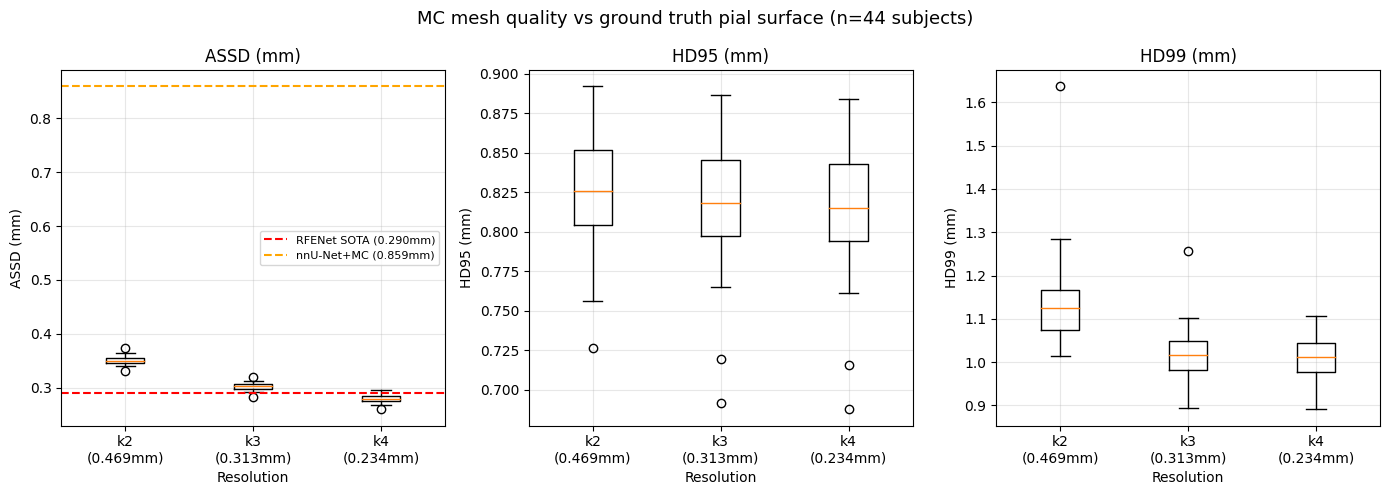

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, metric, label in zip(
    axes,
    ["assd_mm", "hd95_mm", "hd99_mm"],
    ["ASSD (mm)", "HD95 (mm)", "HD99 (mm)"]
):
    data_by_k = [df[df["k_level"] == k][metric].values for k in ["k2", "k3", "k4"]]
    ax.boxplot(data_by_k, labels=["k2\n(0.469mm)", "k3\n(0.313mm)", "k4\n(0.234mm)"])
    ax.set_xlabel("Resolution")
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.grid(True, alpha=0.3)
    
    # Add RFENet reference line on ASSD plot
    if metric == "assd_mm":
        ax.axhline(y=0.290, color="red", linestyle="--", linewidth=1.5, label="RFENet SOTA (0.290mm)")
        ax.axhline(y=0.859, color="orange", linestyle="--", linewidth=1.5, label="nnU-Net+MC (0.859mm)")
        ax.legend(fontsize=8)

plt.suptitle("MC mesh quality vs ground truth pial surface (n=44 subjects)", fontsize=13)
plt.tight_layout()
plt.savefig("preliminary_results.png", dpi=150, bbox_inches="tight")
plt.show()